# Pagerank - Sprawozdanie - Jakub Własiewicz

Niektóre funkcje są zdefiniowane na potrzebę podglądu, ale na wypadek są też zincludowane. Bardzo zalecam kliknąć "Run all", ponieważ dalsze skrawki kodu mogą trochę długo się wykonywać ze względu na naturę Julii i Jupyter notebook'a

### Importy

In [1]:
include("src/pagerank.jl");
include("src/simplerank.jl");
include("src/plotting.jl")
using .simplerank
using .pagerank
using .plotting
using Karnak
using Arpack
using LinearAlgebra
using Graphs
using Plots
using Statistics
import Graphs: pagerank as pagerank_lib

## Zadanie 1 - Prosty ranking

Ranking wierzchołka $u$ definujemy w następujący sposób:

$$ r(u) = d \sum_{v \in B_u} \frac{r(v)}{N_v}$$

Gdzie $d \in (0,1]$ jest parametrem tłumienia, $B_u$ poprzednikiami $u$, $N_v$ stopniem wyjściowym $v$.
Równanie w postaci macierzowej sprowadza się do:

$$ \textbf{r} = d \textbf{Ar} $$
$$ A_{u,v} = \begin{cases}
            \frac{1}{N_v} & \text{jeśli $(v, u) \in E$,} \\
            0 & \text{w.p.p.}\\ \end{cases}

Możemy znaleźć rozwiązanie za pomocą metody potęgowej, otrzymując wektor własny macierzy $d\textbf{A}$ odpowiadający wartości własnej $\lambda = 1$

In [2]:
function graph_simplerank(graph, d=1.0, iters=100000, ϵ=10E-30)
    @assert 0.0 < d <= 1.0
    A = matrix_A(graph) # stworzenie macierzy A z grafu
    v = power_iteration(d * A, iters, ϵ)
    v[v.<ϵ] .= 0.0 # zastąpienie wartości < ϵ zerem
    return any(v .< 0) ? -v : v # jeśli wektor jest cały ujemny, zmień znak
end

graph_simplerank (generic function with 4 methods)

### Graf Erdős–Rényi

In [3]:
n = 15
erdos = erdos_renyi(n, 1.1 * log(n) / n, is_directed=true)
while !all(outdegree(erdos) .> 0) # spójność
    erdos = erdos_renyi(n, 1.1 * log(n) / n, is_directed=true)
end
A = matrix_A(erdos)
λᵥ₁ = normalize(abs.(eigs(A)[2][:, 1]), 1) # dominujący wektor bibliotecznej funkcji
λᵥ₂ = simplerank.power_iteration(A)
λᵥ₁ - λᵥ₂ # różnica wartości wektorów własnych 

┌ Info: power iteration return because of norm < ϵ
└ @ Main.simplerank /home/hyperbarq/Documents/pagerank/src/simplerank.jl:25


15-element Vector{Float64}:
  1.3877787807814457e-17
  2.7755575615628914e-17
 -5.551115123125783e-17
 -2.0816681711721685e-17
 -2.0816681711721685e-17
 -1.3877787807814457e-17
  2.7755575615628914e-17
 -1.3877787807814457e-17
  1.3877787807814457e-17
 -1.3877787807814457e-17
  2.0816681711721685e-17
  8.326672684688674e-17
 -6.938893903907228e-17
  0.0
 -1.3877787807814457e-17

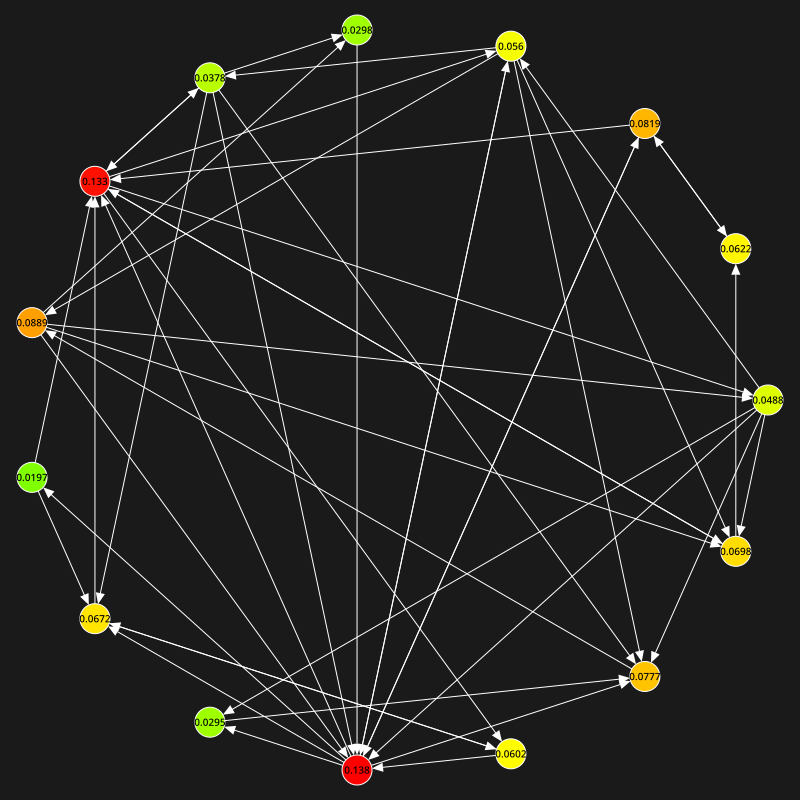

In [4]:
d = 0.85
plotting.plot_pagerank(erdos, d, simplerank.graph_simplerank, shell)

### Graf Scale-Free - Barabási–Albert Model

In [5]:
n = 15
bara = barabasi_albert(n,Int(round(n/3)), is_directed=true, complete=true)
A = matrix_A(bara)
λᵥ₁ = normalize(abs.(eigs(A)[2][:, 1]), 1) # dominujący wektor bibliotecznej funkcji
λᵥ₂ = simplerank.power_iteration(A)
λᵥ₁ - λᵥ₂ # różnica wartości wektorów własnych 

┌ Info: power iteration return because of norm < ϵ
└ @ Main.simplerank /home/hyperbarq/Documents/pagerank/src/simplerank.jl:25


15-element Vector{Float64}:
 -5.551115123125783e-17
  0.0
 -2.7755575615628914e-17
  2.7755575615628914e-17
 -5.551115123125783e-17
  3.0594944914230825e-17
  2.837007373487039e-17
  4.859227624782621e-18
  2.239476289266881e-17
  5.562458676553563e-17
  9.977366165142287e-18
  7.924817049003364e-18
  5.863904677148416e-18
  2.659642479396322e-18
  3.311292382445519e-17

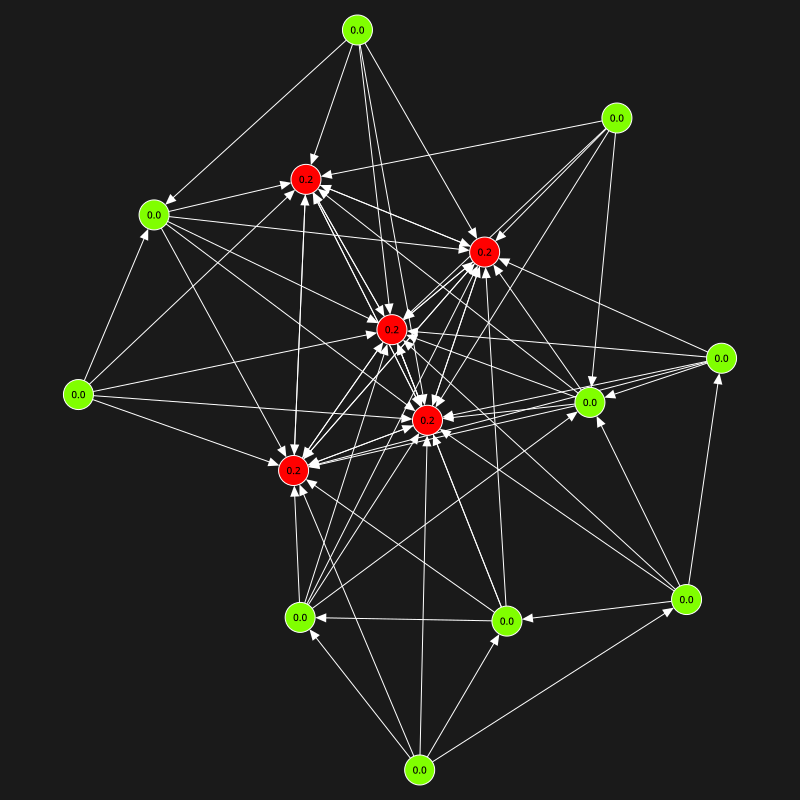

In [6]:
d = 0.85
plotting.plot_pagerank(bara, d, simplerank.graph_simplerank, stress)

### Graf Small World - Watts-Strogatz model

In [7]:
n = 15
watts_stro = watts_strogatz(n, n ÷ 2, 0.6, is_directed=true)
while !all(outdegree(watts_stro) .> 0) # spójność
    watts_stro = watts_strogatz(n, n ÷ 2, 0.6, is_directed=true)
end
A = matrix_A(watts_stro)
λᵥ₁ = normalize(abs.(eigs(A)[2][:, 1]), 1) # dominujący wektor bibliotecznej funkcji
λᵥ₂ = simplerank.power_iteration(A)
λᵥ₁ - λᵥ₂ # różnica wartości wektorów własnych

15-element Vector{Float64}:
 -1.3877787807814457e-17
  0.0
 -6.938893903907228e-18
  5.551115123125783e-17
  6.938893903907228e-17
  5.551115123125783e-17
 -1.3877787807814457e-17
  1.3877787807814457e-17
 -2.0816681711721685e-17
  5.551115123125783e-17
  6.938893903907228e-18
  6.245004513516506e-17
 -6.938893903907228e-18
 -2.7755575615628914e-17
  0.0

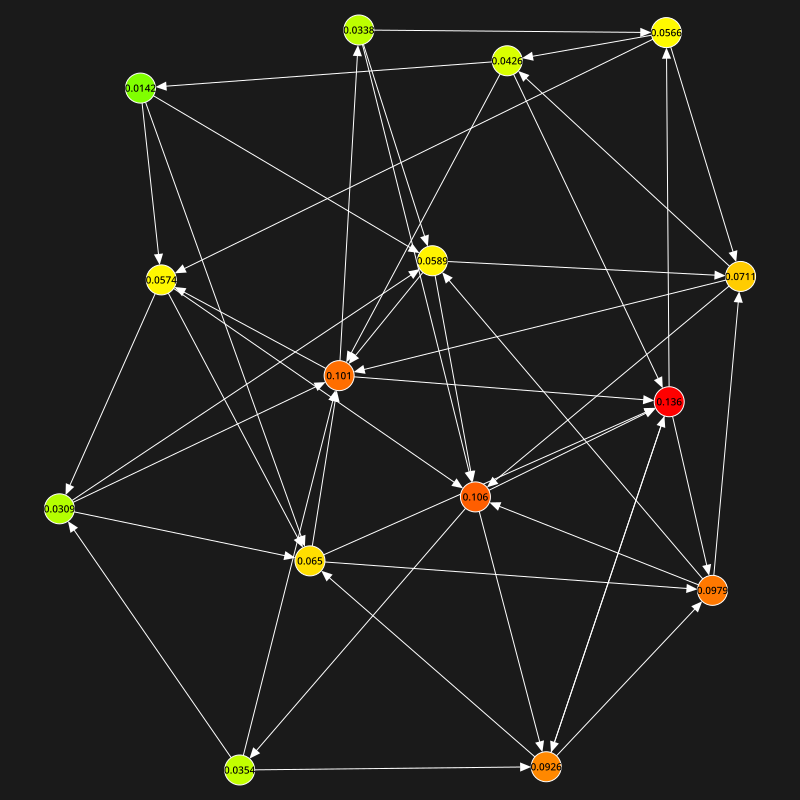

In [8]:
d = 0.85
plotting.plot_pagerank(watts_stro, d, simplerank.graph_simplerank, stress)

## Zadanie 2 - Pagerank

Tym razem mamy równanie:

$$ r(u) = d \sum_{v \in B_u} \frac{r(v)}{N_v} + (1-d)e(u)$$

Gdzie $\mathbf{e}$ jest wektorem preferencji teleportacji, oraz wprowadzimy $\hat{A}$ - macierz w których zerowe kolumny wiszących wierzchołków są zastąpione wektorem $\mathbf{e}$. $\mathbf{c}$ to wskaźnik wiszących.

$$ \hat{A} = A + \mathbf{e c}^T$$

In [9]:
function matrix_Â(graph, e)
    A = simplerank.matrix_A(graph)
    n = nv(graph)
    dangling = findall(x -> x == 0, outdegree(graph))

    m = length(dangling)
    I = Vector{Int}(undef, n * m)
    J = Vector{Int}(undef, n * m)
    V = Vector{Float64}(undef, n * m)

    idx = 1
    for col in dangling
        for row in 1:n
            I[idx] = row
            J[idx] = col
            V[idx] = e[row]
            idx += 1
        end
    end

    return A + sparse(I, J, V, n, n)
end

matrix_Â (generic function with 1 method)

Zastosujemy sprytną metodę potęgową, zamiast liczyć bezpośrednio dla macierzy $d \mathbf{A} + (1-d) \mathbf{ec}^T$ - pamięciowo $O(n^2)$

In [10]:
function pagerank_power_iter_with_mass_re(A, d, e, ϵ) #A - macierz, d - wsp. tlum. , e - wektor teleportacji
    rᵢ = e
    rᵢ₊₁ = rᵢ
    δ = Inf
    while ϵ < δ
        rᵢ = rᵢ₊₁
        rᵢ₊₁ = d * A * rᵢ
        ρ = norm(rᵢ, 1) - norm(rᵢ₊₁, 1)
        rᵢ₊₁ += ρ * e
        δ = norm(rᵢ₊₁ - rᵢ, 1)
    end
    return rᵢ
end

pagerank_power_iter_with_mass_re (generic function with 1 method)

### Wizualizacje i sprawdzenie poprawności

Wykorzystamy znowu graf Erdős–Rényi

In [11]:
n = 25
d = 0.85
erdos = erdos_renyi(n, 1.1 * log(n) / n, is_directed=true)
pg = pagerank.graph_pagerank(erdos, d) # sprytna metoda potegowa
pg_basic = pagerank.graph_pagerank_basic(erdos, d) # naiwna
pg_lib = pagerank_lib(erdos, d) # biblioteczna
display(pg - pg_basic)
display(pg - pg_lib)
display(pg_basic - pg_lib)

25-element Vector{Float64}:
  5.898059818321144e-17
  2.706168622523819e-16
 -1.734723475976807e-16
 -3.469446951953614e-16
  4.163336342344337e-17
  9.71445146547012e-17
 -1.5265566588595902e-16
 -2.7755575615628914e-17
  3.3306690738754696e-16
 -4.440892098500626e-16
  ⋮
  2.0816681711721685e-16
 -6.245004513516506e-17
  1.2836953722228372e-16
 -1.5265566588595902e-16
  1.5265566588595902e-16
  1.5612511283791264e-16
 -9.71445146547012e-17
 -7.28583859910259e-17
  4.371503159461554e-16

25-element Vector{Float64}:
 -1.852784177122646e-8
 -3.0459858858800093e-7
  3.8266402661857324e-7
  3.153048188861418e-7
  2.7343472493168708e-8
 -1.406676993914724e-7
  2.0609793460746317e-7
 -1.3763887436041289e-8
 -2.1370732794512293e-7
  2.2014168704620474e-7
  ⋮
 -3.1322531314492696e-7
  1.9361508905163527e-7
 -1.2295896178321497e-7
  2.0609793460746317e-7
 -2.029834685612908e-7
  6.761335367630461e-8
  1.725515736579475e-7
  6.954707600093091e-8
 -1.4693538157722896e-7

25-element Vector{Float64}:
 -1.852784183020706e-8
 -3.045985888586178e-7
  3.826640267920456e-7
  3.153048192330865e-7
  2.7343472451535344e-8
 -1.406676994886169e-7
  2.0609793476011884e-7
 -1.3763887408285713e-8
 -2.1370732827818983e-7
  2.2014168749029395e-7
  ⋮
 -3.132253133530938e-7
  1.9361508911408531e-7
 -1.229589619115845e-7
  2.0609793476011884e-7
 -2.0298346871394646e-7
  6.76133535201795e-8
  1.72551573755092e-7
  6.95470760737893e-8
 -1.4693538201437928e-7

Różnice są nieznacze, rzędu $ \approx 10^{-7}$ (dla $n=25$), więc w tym przypadku można twierdzić o poprawności zaimplementowanej funkcji.
Możemy też sprawdzić średnie różnice pomiędzy implementacjami dla różnych $d$:

In [12]:
avgs = []
erdos = erdos_renyi(n, 1.1 * log(n) / n, is_directed=true)
for d ∈ [0.5, 0.6, 0.75, 0.85, 0.9]
    pg = pagerank.graph_pagerank(erdos, d) # sprytna metoda potegowa
    pg_basic = pagerank.graph_pagerank_basic(erdos, d) # naiwna
    pg_lib = pagerank_lib(erdos, d) # biblioteczna
    push!(avgs, mean(mean.([pg - pg_basic, pg - pg_lib, pg_basic - pg_lib])))
end
display(avgs)

5-element Vector{Any}:
  1.8133642735544226e-17
  3.524958103184872e-17
  5.1671629937762504e-17
  8.419191270074103e-18
 -2.620588931042296e-17

┌ Info: power iteration return because of norm < ϵ
└ @ Main.pagerank.simplerank /home/hyperbarq/Documents/pagerank/src/simplerank.jl:25


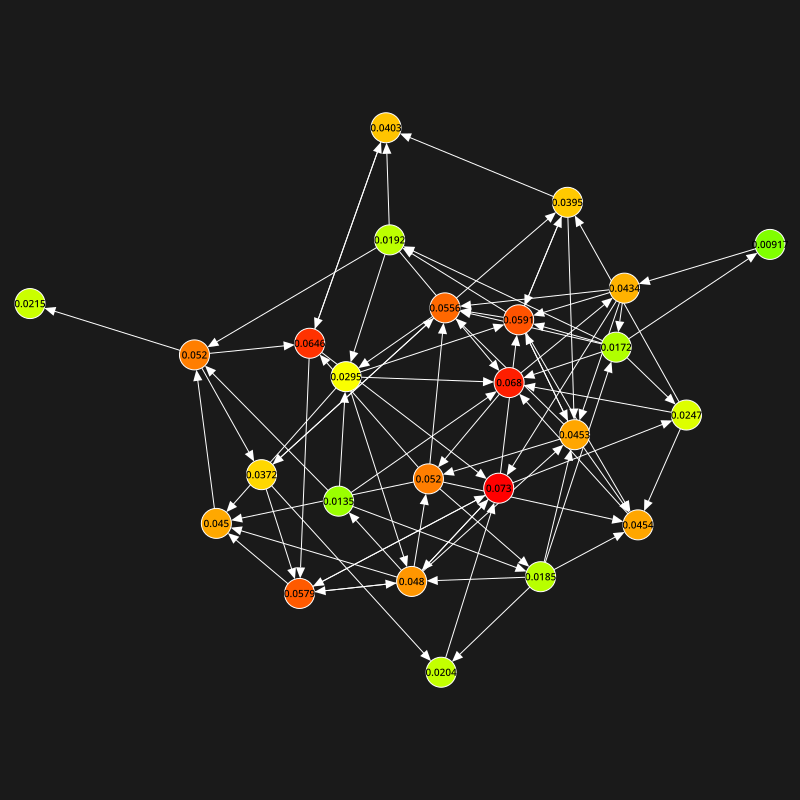

In [13]:
plotting.plot_pagerank(erdos, d, pagerank.graph_pagerank, stress)

Sprawdźmy wykres δᵢ = ||rᵢ₊₁ - rᵢ||₁ w półlogarytmicznej skali.

"Nachylenie: -0.6598908971454421 vs teoretyczne : -0.16251892949777494"

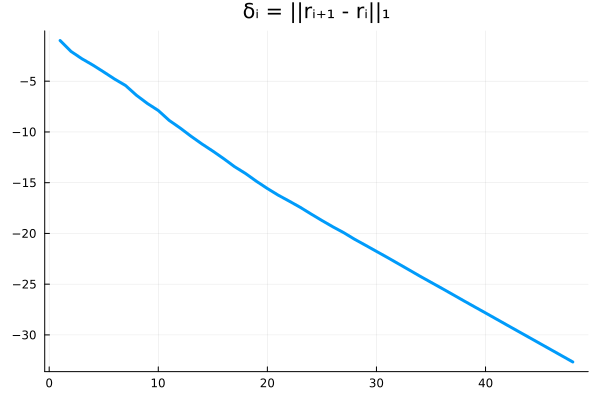

In [14]:
pg, delta_v = pagerank.graph_pagerank(erdos, d, Val(:delta_data))
log_delta_v = log.(delta_v)
display("Nachylenie: $((log_delta_v[end] - log_delta_v[1]) / length(delta_v)) vs teoretyczne : $(log(d))")
plot(1:length(delta_v), log_delta_v, title="δᵢ = ||rᵢ₊₁ - rᵢ||₁", linewidth=3, legend=false)

Histogram wartości Page Rank (logarytmiczna skala pionowa)

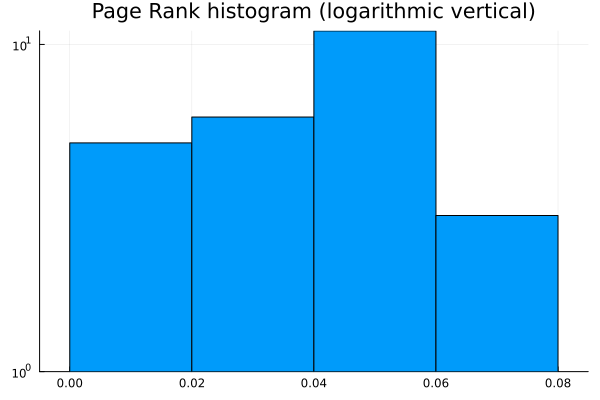

In [15]:
histogram(pg, yaxis=(:log10), legend= false, title="Page Rank histogram (logarithmic vertical)")

Log-log wykres rozrzutu wartości Page Rank od $|B_u|$ (stopnia wejściowego)

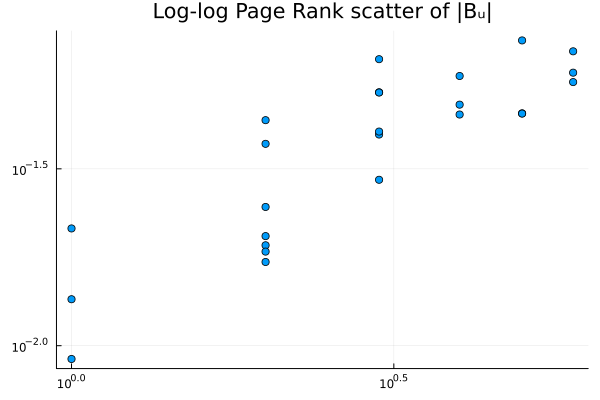

In [16]:
x = []
y = []
indegrees = replace(indegree(erdos), 0=>1)
for v in vertices(erdos)
    push!(x, indegrees[v])
    push!(y, pg[v])
end
plot(x, y, seriestype=:scatter, xscale=:log10, yscale=:log10, title="Log-log Page Rank scatter of |Bᵤ|", legend=false)

Top $k$ wierzchołków dla różnych $d$ - inaczej miara przecięcia top $k$ indeksów dla $d=0.85$ z top $k$ dla innych $d \in \{0.1,0.2,0.3, 0.5, 0.6, 0.75, 0.85, 0.9\}$

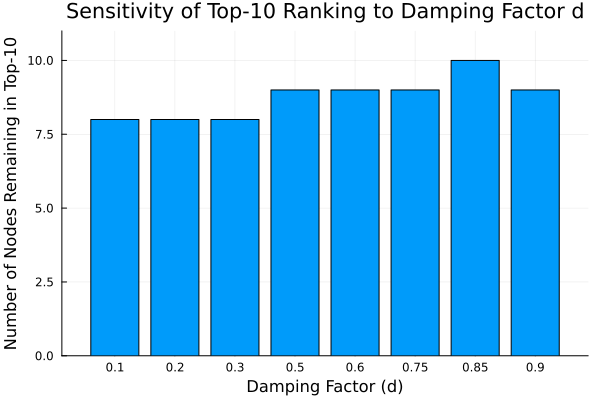

In [17]:
k = 10
counts = []
top_k = sortperm(pg, rev=true)[1:k]
d_values = [0.1,0.2,0.3, 0.5, 0.6, 0.75, 0.85, 0.9]
for d in d_values
    current_pg = pagerank.graph_pagerank(erdos, d)
    current_top_k = sortperm(current_pg, rev=true)[1:k]
    matches = length(intersect(top_k, current_top_k))
    push!(counts, matches)
end
bar(string.(d_values), counts, 
        title="Sensitivity of Top-$k Ranking to Damping Factor d",
        xlabel="Damping Factor (d)", 
        ylabel="Number of Nodes Remaining in Top-$k",
        legend=false,
        ylimits=(0, k+1))

### Zmiana $\mathbf{e}$

Spróbujmy teraz zmienić wektor teleportacji tak aby był zcentrowany na jakimś wierzchołku o niskim stopniu wejściowym


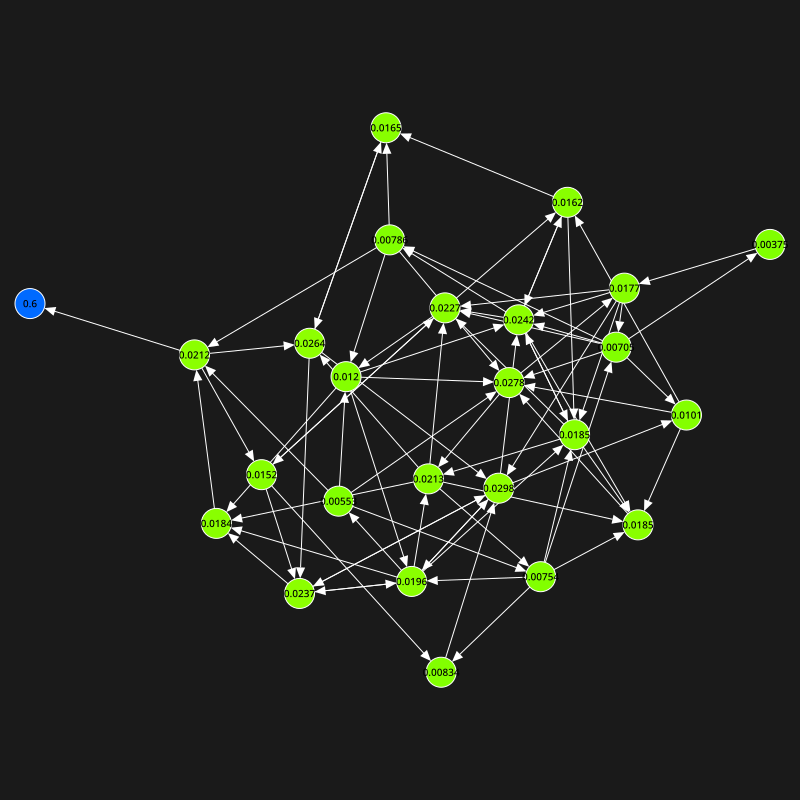

In [18]:
d = 0.85
importance = 0.9 #ważność tego pojedynczego wierzchołka
min_v = argmin(indegree(erdos))
e = zeros(nv(erdos))
e .= (1 - importance) / (nv(erdos) - 1)
e[min_v] = importance
pg = pagerank.graph_pagerank(erdos, d, e)
pg = round.(sigdigits=3, pg)
@drawsvg begin
        background("grey10")
        sethue("white")
        drawgraph(erdos,
            layout=stress,
            edgegaps=15.0,
            vertexlabels=pg,
            vertexshapesizes=15,
            vertexfillcolors=
            [i != min_v ? HSV(plotting.color_lerp(x, minimum(pg), maximum(pg)), 1.0, 1.0) : HSV(215.0, 1.0, 1.0) #niebieskim ten wierzchołek kolorujemy
             for (i, x) in enumerate(pg)]
        )
    end 800 800

Możemy zauważyć, że teraz ten wierzchołek (oznaczony na niebiesko) ma najwyższą wartość Page Rank, nawet przy $d = 0.85$

## Test na grafie "web-Stanford"

Powyższe wyniki mogą być niezadowalające pod kątem wielkości grafu, zatem przejdziemy teraz przez powyższe wizualizacje, ale dla grafu "web-Stanford" opartego na stronach z sieci stanford.edu, wziętego ze strony [snap.stanford.edu](https://snap.stanford.edu/data/web-Stanford.html).

In [19]:
stanford = loadgraph("web-Stanford.txt")

{281903, 2312497} directed simple Int64 graph

In [20]:
d = 0.85
pg = pagerank.graph_pagerank(stanford, d) 
pg_lib = pagerank_lib(stanford, d) # biblioteczna
display(pg - pg_lib)

281903-element Vector{Float64}:
 -1.2006876977767834e-10
 -3.77208833271287e-5
 -1.3472337484811e-7
 -1.2006876977767834e-10
 -1.8873290067496404e-7
  2.2194421663631596e-7
  8.453963859171087e-7
 -1.2006876977767834e-10
 -4.147026341487289e-7
 -4.2188329124896415e-7
  ⋮
  3.069626612349489e-7
  5.3547255187236946e-8
 -1.2135819969822154e-7
 -6.717026271250959e-8
  1.1436503473609463e-7
 -1.2520898867503706e-10
 -1.2090279192870941e-10
 -8.063026411739178e-8
 -3.3551452622851845e-7

Niestety, dla tak dużych grafów, wartości Page Rank są małych rzędów, więc dla niektórych wierzchołków różnica jest tego samego rzędu, ale nie powinno to dla nas mieć większego znaczenia bo może to wynikać po prostu z różnicy w implementacji.

In [ ]:
pg, delta_v = pagerank.graph_pagerank(stanford, d, Val(:delta_data))
log_delta_v = log.(delta_v)
display("Nachylenie: $((log_delta_v[end] - log_delta_v[1]) / length(delta_v)) vs teoretyczne : $(log(d))")
p1 = plot(1:length(delta_v), log_delta_v, linewidth=3, legend=false)

p2 = histogram(pg, yaxis=(:log10), legend= false)

x = []
y = []
indegrees = replace(indegree(stanford), 0=>1)
for v in vertices(stanford)
    push!(x, indegrees[v])
    push!(y, pg[v])
end
p3 = plot(x, y, seriestype=:scatter, xscale=:log10, yscale=:log10, legend=false)

k = 10
counts = []
top_k = sortperm(pg, rev=true)[1:k]
d_values = [0.1,0.2,0.3, 0.5, 0.6, 0.75, 0.85, 0.9]
for d in d_values
    current_pg = pagerank.graph_pagerank(stanford, d)
    current_top_k = sortperm(current_pg, rev=true)[1:k]
    matches = length(intersect(top_k, current_top_k))
    push!(counts, matches)
end
p4 = bar(string.(d_values), counts, 
        legend=false,
        ylimits=(0, k+1))
plot(p1, p2, p3, p4, layout=(2,2), legend=false, size=(800,800))